Model R^2 Score: 0.8116992390738805


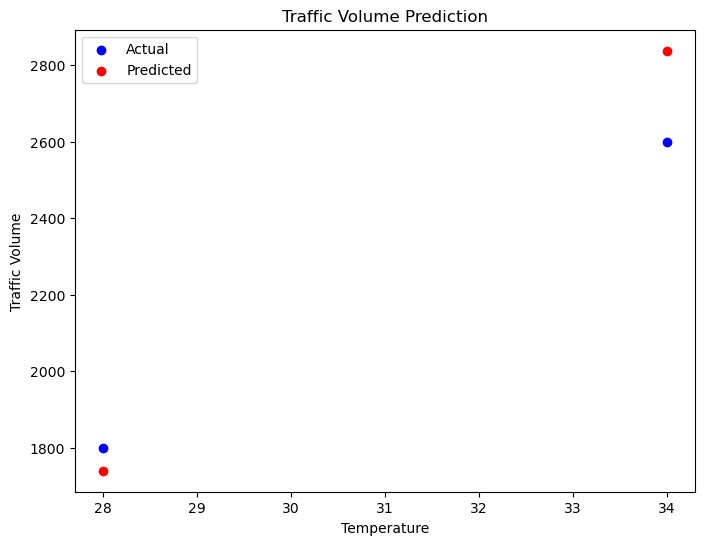

KeyError: "None of [Index(['weather'], dtype='object')] are in the [columns]"

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("../data/traffic.csv")

# Ensure numeric values
df["temp"] = pd.to_numeric(df["temp"], errors="coerce")
df["traffic_volume"] = pd.to_numeric(df["traffic_volume"], errors="coerce")

# Features and target
X = df[["temp"]]
y = df["traffic_volume"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
score = model.score(X_test, y_test)
print("Model R^2 Score:", score)

# Visualization: Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.scatter(X_test, model.predict(X_test), color="red", label="Predicted")
plt.xlabel("Temperature")
plt.ylabel("Traffic Volume")
plt.title("Traffic Volume Prediction")
plt.legend()

# Save BEFORE showing
plt.savefig("../visualizations/sample_graph.png")
plt.show()
# Feature engineering
df["hour"] = pd.to_datetime(df["time"], format="%H:%M").dt.hour

# Convert categorical weather to numeric (one-hot encoding)
df = pd.get_dummies(df, columns=["weather"], drop_first=True)

# Features: temperature, hour, rain, holiday, weather
X = df[["temp", "hour", "rain", "holiday"] + [col for col in df.columns if col.startswith("weather_")]]
y = df["traffic_volume"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
score = model.score(X_test, y_test)
print("Model R^2 Score with multiple features:", score)


In [1]:
import pandas as pd

# Road network data
roads = pd.read_csv("../data/road_network.csv")
print("Roads:", roads.shape)
print(roads.head())

# Traffic sensor data
traffic = pd.read_csv("../data/traffic_sensor_data.csv")
print("Traffic:", traffic.shape)
print(traffic.head())

# Weather conditions
weather = pd.read_csv("../data/weather_conditions.csv")
print("Weather:", weather.shape)
print(weather.head())

# Traffic events
events = pd.read_csv("../data/traffic_events.csv")
print("Events:", events.shape)
print(events.head())


Roads: (200, 18)
   road_id      road_name       road_type  length_km  lanes  speed_limit_kmh  \
0  RD-0001  Jl. Segment 1  Jalan Kolektor        4.3      4               60   
1  RD-0002  Jl. Segment 2    Jalan Arteri        4.3      4               80   
2  RD-0003  Jl. Segment 3     Jalan Lokal        1.8      2               40   
3  RD-0004  Jl. Segment 4  Jalan Kolektor        1.8      4               60   
4  RD-0005  Jl. Segment 5       Jalan Tol       22.7      4               80   

   capacity_vehicles_per_hour  has_bus_lane  has_bike_lane surface_condition  \
0                        5384             0              0             Cukup   
1                        6132             0              0              Baik   
2                         978             0              0             Cukup   
3                        4160             0              1       Rusak Berat   
4                        6600             1              0              Baik   

  last_maintenance_da

In [2]:
import json

# Sensor locations
with open("../data/sensor_locations.json") as f:
    sensors = json.load(f)
print("Sensors sample:", sensors[:2])

# Prediction config
with open("../data/traffic_prediction_config.json") as f:
    config = json.load(f)
print("Config:", config)


KeyError: slice(None, 2, None)

In [3]:
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218400 entries, 0 to 218399
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          218400 non-null  object 
 1   sensor_id          218400 non-null  object 
 2   location           218400 non-null  object 
 3   direction          218400 non-null  object 
 4   vehicle_count      218400 non-null  int64  
 5   average_speed_kmh  218400 non-null  float64
 6   occupancy_rate     218400 non-null  float64
 7   congestion_level   218400 non-null  object 
 8   car_count          218400 non-null  int64  
 9   motorcycle_count   218400 non-null  int64  
 10  truck_count        218400 non-null  int64  
 11  bus_count          218400 non-null  int64  
 12  day_of_week        218400 non-null  int64  
 13  is_holiday         218400 non-null  int64  
 14  hour               218400 non-null  int64  
dtypes: float64(2), int64(8), object(5)
memory usage: 25

In [4]:
traffic.describe()


,vehicle_count,average_speed_kmh,occupancy_rate,car_count,motorcycle_count,truck_count,bus_count,day_of_week,is_holiday,hour
count,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000
mean,39.238462,57.978488,0.241431,16.176296,14.213397,2.053608,6.795783,3.000000,0.329670,11.500000
std,28.509697,22.526444,0.142765,12.315940,10.885097,2.100901,4.994987,2.000005,0.470094,6.922202
min,0.000000,7.700000,0.025000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,36.400000,0.129000,7.000000,6.000000,1.000000,3.000000,1.000000,0.000000,5.750000
50%,32.000000,64.000000,0.222000,13.000000,11.000000,1.000000,5.000000,3.000000,0.000000,11.500000
75%,55.000000,80.000000,0.317000,23.000000,20.000000,3.000000,9.000000,5.000000,1.000000,17.250000
max,138.000000,80.000000,0.580000,67.000000,61.000000,13.000000,41.000000,6.000000,1.000000,23.000000


In [5]:
traffic.isna().sum()


timestamp            0
sensor_id            0
location             0
direction            0
vehicle_count        0
average_speed_kmh    0
occupancy_rate       0
congestion_level     0
car_count            0
motorcycle_count     0
truck_count          0
bus_count            0
day_of_week          0
is_holiday           0
hour                 0
dtype: int64